In [ ]:
#!pip install matplotlib
#!pip install scipy
#!pip install scikit-learn

#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126 
# Im using my GPU so I need this line to install the right version of pytorch
# You can remove it if you are using CPU

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Subset, ConcatDataset
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, roc_auc_score

In [2]:
import torch
print(torch.cuda.is_available())        # Should print True
print(torch.cuda.get_device_name(0))    # Your GPU name

True
NVIDIA GeForce RTX 3060 Ti


In [ ]:
batch_size = 128
torch.manual_seed(0)
# dataset is RGB ie. 3 channels
# images in the dataset have varying sizes
# mean and std value used for normalisartion follows standard practice values of imagenet since ResNet that we are using is pretrained on imagenet
# ResNet50 req dimensions of images to be 224

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]) 
])

train_dataset = datasets.Flowers102('data', split = 'train', download=True, transform = transform)
validation_dataset = datasets.Flowers102('data', split = 'val', download=True, transform = transform)
test_dataset = datasets.Flowers102('data', split = 'test', download=True, transform = transform)

torch.manual_seed(1)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader  = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.1484594].


torch.Size([128, 3, 224, 224])


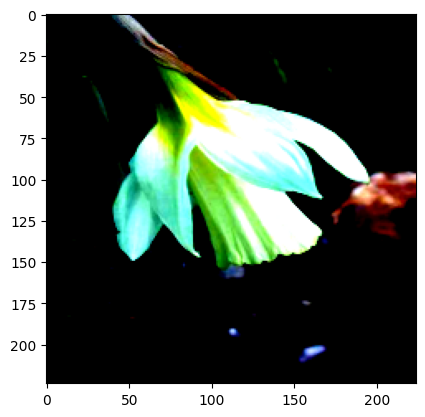

In [4]:
# select a random sample
images, labels = next(iter(train_loader))
print(images.shape)
plt.imshow(images[0].permute(1, 2, 0))

## Transfer learning - using pytorch ResNet50 as baseline model
Unfreeze final fully connected layer, and fine-tune new one for our classifcation task on the flower102 dataset.  
Our fc head only consist of 1 layer - decided so as the classification head doesnt have to be overly complicated cause the training data dont really significantly differ  
`Finding optimal learning rate`

In [8]:
class EarlyStopper:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, train_correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)  
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    train_loss /= size
    train_correct /=size

    return train_loss, train_correct

def validation_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)  
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            val_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss /= size
    val_correct /= size
    
    return val_loss, val_correct

In [ ]:
# using kfold validation and obtaining mean accuracy to evaluate performance of different learning rates
cross_validation = KFold(n_splits=5, shuffle=True, random_state=42)
lr_list = [0.0001, 0.0005, 0.001, 0.005, 0.01]

train_dict = {}
val_dict = {}

for lr in lr_list:
    train_dict[lr] = []
    val_dict[lr] = []
    
    for train_index, val_index in cross_validation.split(train_dataset):

        train_subset = Subset(train_dataset, train_index)
        val_subset = Subset(train_dataset, val_index)
        
        train_dict[lr].append(train_subset)
        val_dict[lr].append(val_subset)

In [ ]:
# this is the training and evaluation loop
batch_size = 128

mean_val_acc = {}

for lr in lr_list:
    acc_list = []

    for fold in range(5):
        train_fold = train_dict[lr][fold]
        val_fold   = val_dict[lr][fold]
        
        train_loader = torch.utils.data.DataLoader(train_fold, batch_size=batch_size, shuffle=True)
        val_loader   = torch.utils.data.DataLoader(val_fold, batch_size=batch_size, shuffle=False)

        model = models.resnet50(pretrained=True)

        for param in model.parameters():
            param.requires_grad = False

        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 102) 
        model = model.to(device)
        
        # added regularization
        optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=0.01) 
        loss_fn = nn.CrossEntropyLoss()
        early_stopper = EarlyStopper(patience=5, min_delta=0.0001)

        for t in range(20): # just to speed up testing
            model.train()
            train_loss, train_correct = train_loop(train_loader, model, loss_fn, optimizer)

            model.eval()
            val_loss, val_correct = validation_loop(val_loader, model, loss_fn)
            if early_stopper.early_stop(val_loss):
                print("Early stopping triggered!")
                break
        
        acc_list.append(val_correct)

    mean_val_acc[lr] = np.mean(acc_list)


Using device: cuda
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!
Early stopping triggered!


Text(0.5, 1.0, 'Mean Validation Accuracy vs Learning Rate')

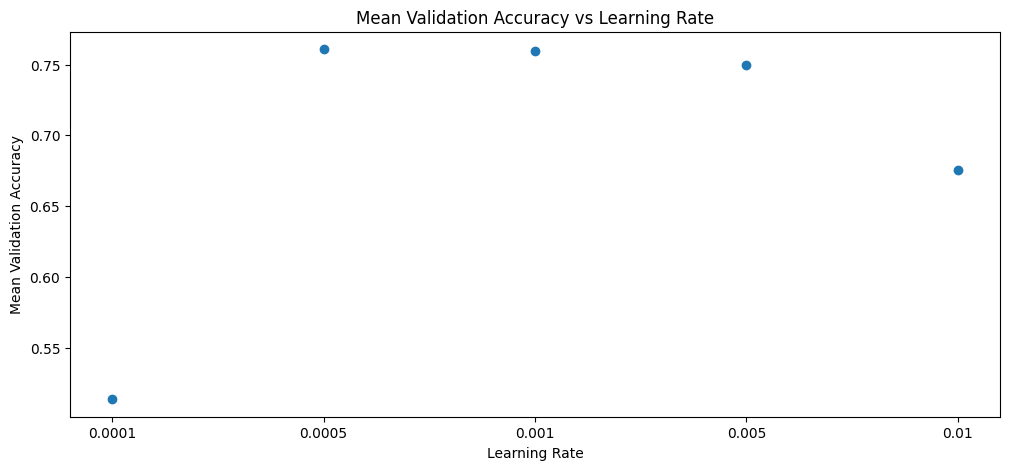

In [13]:
plt.figure(figsize=(12, 5))
# scatterplot - Mean Validation Accuracy vs lr [0.0001, 0.0005, 0.001, 0.005, 0.01]
x_positions = range(len(lr_list))  # 0,1,2,3,4
y_acc_values = [mean_val_acc[lr] for lr in lr_list]
plt.scatter(x_positions, y_acc_values, marker='o')
plt.xticks(x_positions, lr_list)
plt.xlabel("Learning Rate")
plt.ylabel("Mean Validation Accuracy")
plt.title("Mean Validation Accuracy vs Learning Rate")

learning rate = 0.0005 gives us the best performance when number of epochs is set to 20

## Train and Test - with optimal learning rate = 0.0005

In [14]:
# training on train + validation set
full_train_dataset = ConcatDataset([train_dataset, validation_dataset])

torch.manual_seed(1)

train_loader = torch.utils.data.DataLoader(full_train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [15]:
# using the same train_loop in the previous cells
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)  
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            test_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= size
    test_correct /= size
    
    return test_loss, test_correct

In [19]:
model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 102) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = model.to(device)

lr = 0.0005 # based on previous results
num_epochs = 100

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=0.01)

patience = 5
early_stopper = EarlyStopper(patience=patience, min_delta=0.0001)

Using device: cuda


In [20]:
tr_loss, tr_correct = [], []
te_loss, te_correct = [], []
for t in range(num_epochs):
    model.train()
    train_loss, train_correct = train_loop(train_loader, model, loss_fn, optimizer)
    model.eval()
    test_loss, test_correct = validation_loop(test_loader, model, loss_fn)
    
    tr_loss.append(train_loss), tr_correct.append(train_correct)
    te_loss.append(test_loss), te_correct.append(test_correct)
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Early stopping triggered!")
        break

Epoch 1: Train_accuracy: 8.58%, Train_loss: 0.032535, Test_accuracy: 29.27%, Test_loss: 0.031536
Epoch 2: Train_accuracy: 44.61%, Train_loss: 0.026123, Test_accuracy: 58.42%, Test_loss: 0.026463
Epoch 3: Train_accuracy: 70.64%, Train_loss: 0.020786, Test_accuracy: 74.21%, Test_loss: 0.021952
Epoch 4: Train_accuracy: 80.49%, Train_loss: 0.016560, Test_accuracy: 78.52%, Test_loss: 0.018439
Epoch 5: Train_accuracy: 84.51%, Train_loss: 0.013307, Test_accuracy: 81.15%, Test_loss: 0.015961
Epoch 6: Train_accuracy: 88.04%, Train_loss: 0.010824, Test_accuracy: 82.76%, Test_loss: 0.013925
Epoch 7: Train_accuracy: 89.31%, Train_loss: 0.008957, Test_accuracy: 83.74%, Test_loss: 0.012469
Epoch 8: Train_accuracy: 89.95%, Train_loss: 0.007729, Test_accuracy: 84.37%, Test_loss: 0.011384
Epoch 9: Train_accuracy: 91.18%, Train_loss: 0.006613, Test_accuracy: 84.94%, Test_loss: 0.010459
Epoch 10: Train_accuracy: 90.98%, Train_loss: 0.005857, Test_accuracy: 85.84%, Test_loss: 0.009894
Epoch 11: Train_accu

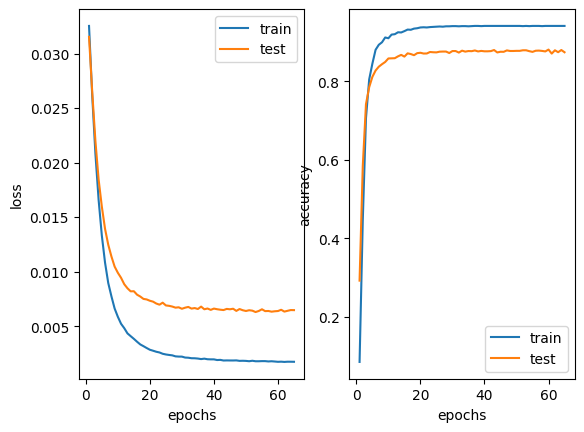

In [21]:
fig, axs = plt.subplots(1, 2)
axs[0].plot(range(1,len(tr_loss)+1), tr_loss, label='train')
axs[0].plot(range(1,len(te_loss)+1), te_loss, label='test')
axs[0].set_xlabel('epochs')
axs[0].set_ylabel('loss')
axs[0].legend()
axs[1].plot(range(1,len(tr_correct)+1), tr_correct, label='train')
axs[1].plot(range(1,len(te_correct)+1), te_correct, label='test')
axs[1].set_xlabel('epochs')
axs[1].set_ylabel('accuracy')
axs[1].legend()

From the above model that has been finetuned, the baseline model achieved 87.41% accuracy  

# Improving results against the baseline model
- Visual Prompt Tuning  
I think visual prompt tuning is more appropriate, cause i think its easier to do that than touching the conv layers eh
- Few Shot Learning 